<a href="https://colab.research.google.com/github/Gchirico63/Didattica/blob/main/PhysicalPropagation/FourierPrimer1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

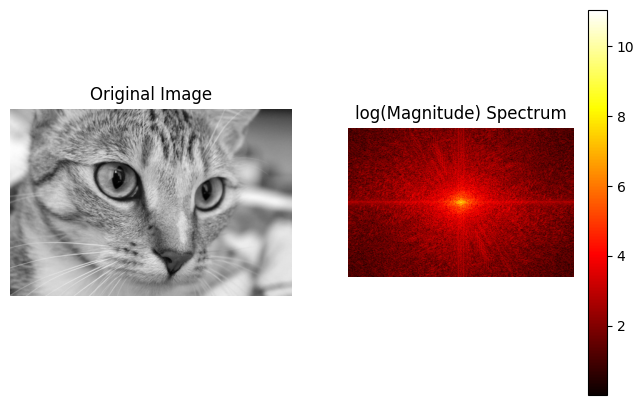

In [5]:
'''
March 2025
Giberto Chirico
This loads a sample image (whatever), RGB and comnvert it in gray scale,
then perform the FFT in 2D.
This is thought to be in colab.
to load an image, first load the image in the "content" folder on colab.
then copy the exacgtf path of the file (right click -> copy path)
'''

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray

# Load a sample image
FLAG = 'cat'  # or 'gravel

if FLAG == 'cat':
  cat     = data.chelsea()
  image = rgb2gray(cat)
elif FLAG == 'gravel':
  image   = data.gravel()
else:
  print ('choose a different image')


# Load a sample image
#image = Image.open('/content/giraffe.jpg').convert('L')  # Convert to grayscale

# Convert image to numpy array
image_array = np.array(image)

# Perform FFT
fft_result = np.fft.fft2(image_array)
fft_shifted = np.fft.fftshift(fft_result)  # Shift zero frequency components to the center
  ######### THIS IS AN ESSENTIAL STEP

# Calculate magnitude spectrum
magnitude_spectrum = np.log(np.abs(fft_shifted) + 1)  # Add 1 to avoid log(0)

# Plot the results
plt.figure(figsize=(8, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(image_array, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Magnitude Spectrum
plt.subplot(1, 2, 2)
#plt.imshow(np.log(magnitude_spectrum), cmap='hot')
im = plt.imshow((magnitude_spectrum), cmap='hot')
plt.title('log(Magnitude) Spectrum')


plt.colorbar(im, cax=cax)

plt.colorbar()
plt.axis('off')

plt.show()


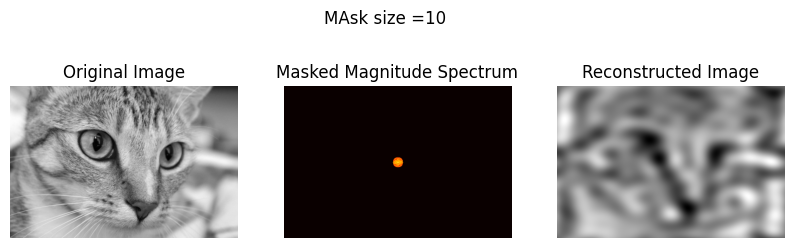

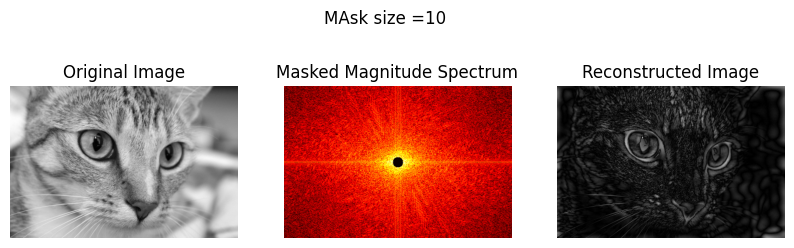

In [22]:
'''
this routine is to show the effect of masking part of the sèpectrum,
In this case we implement a low pass filter.
Exerciese left to the students:
implement a high pass filter'''

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


# Perform FFT
fft_result = np.fft.fft2(image_array)
fft_shifted = np.fft.fftshift(fft_result)  # Shift zero frequency components to the center

# Create a circular mask
rows, cols = image_array.shape
center_row, center_col = rows // 2, cols // 2

radius = 10  # Adjust the radius as needed

radius = np.min([radius,*image_array.shape])

Y, X = np.ogrid[:rows, :cols]
mask = (X - center_col)**2 + (Y - center_row)**2 <= radius**2


# Apply the mask to the FFT spectrum
masked_fft = fft_shifted * mask

# Perform inverse FFT
ifft_shifted = np.fft.ifftshift(masked_fft)  # Shift zero frequency components back
reconstructed_image = np.fft.ifft2(ifft_shifted)
reconstructed_image = np.abs(reconstructed_image)  # Take the absolute value

# Plot the results
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_array, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Masked Magnitude Spectrum
plt.subplot(1, 3, 2)
masked_magnitude_spectrum = np.log(np.abs(masked_fft) + 1)
plt.imshow(masked_magnitude_spectrum, cmap='hot')
plt.title('Masked Magnitude Spectrum')
plt.axis('off')

# Reconstructed Image
plt.subplot(1, 3, 3)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Reconstructed Image')
plt.axis('off')

plt.suptitle('MAsk size ='+str(radius),y=0.8)
plt.show()


#################### reverse filter

MASK = ~mask

# Apply the mask to the FFT spectrum
masked_fft = fft_shifted * MASK ###mask

# Perform inverse FFT
ifft_shifted = np.fft.ifftshift(masked_fft)  # Shift zero frequency components back
reconstructed_image = np.fft.ifft2(ifft_shifted)
reconstructed_image = np.abs(reconstructed_image)  # Take the absolute value

# Plot the results
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_array, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Masked Magnitude Spectrum
plt.subplot(1, 3, 2)
masked_magnitude_spectrum = np.log(np.abs(masked_fft) + 1)
plt.imshow(masked_magnitude_spectrum, cmap='hot')
plt.title('Masked Magnitude Spectrum')
plt.axis('off')

# Reconstructed Image
plt.subplot(1, 3, 3)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Reconstructed Image')
plt.axis('off')

plt.suptitle('MAsk size ='+str(radius),y=0.8)
plt.show()


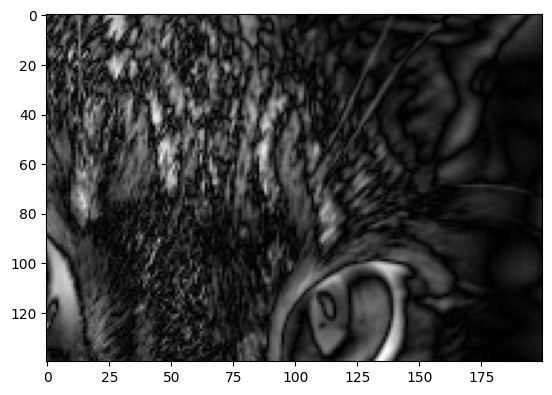

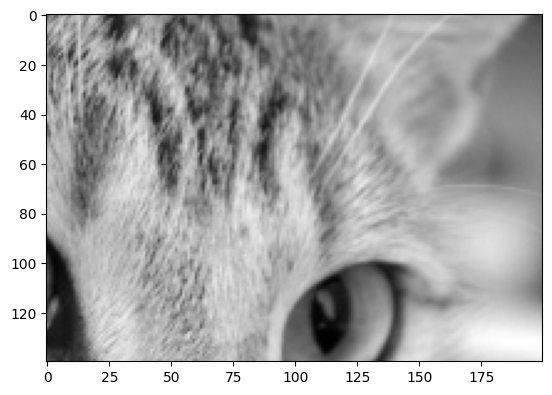

In [23]:
plt.imshow(reconstructed_image[10:150,200:400], cmap='gray')
plt.show()
plt.imshow(image_array[10:150,200:400], cmap='gray')

0 0.7106355799950325 -2.77947037708747
1 11.040660975022522 0.6105559921947801
2 -7.464197247600973 -0.11443935225174846
3 -4.355291276990698 -16.23667971272071
4 0.2931666042778017 0.30582560929819347
5 -7.47311104784653 -1.5044112762307729
6 -3.2361996982108154 3.2211255197914466
7 1.930819359336452 0.7228779884877393
8 2.950384185640968 -0.20285292192984697
9 -2.5617843974009107 0.607957710829328
10 -1.3800659882586557 -0.17342654740594532
11 -0.7931222537165403 0.7078234173779288
12 6.115438000465716 1.668935896493268
13 0.30140450928343404 -0.060244050797558645
14 7.801454867693565 1.0041305296759864
15 14.516894256022363 -6.451950187004691
16 10.402668611349156 -3.9430120185998647
17 -2.4363803516320703 0.25433199416581
18 -9.13807552570193 8.580570912206792
19 6.143369742615434 -3.4137955776880093
20 4.52560175087661 1.6063676873789918
21 16.381940493990683 3.7836738900224876
22 -7.924868673527113 0.782610840863436
23 8.633830047077836 3.525420844041375
24 0.7026750596492659 1.3

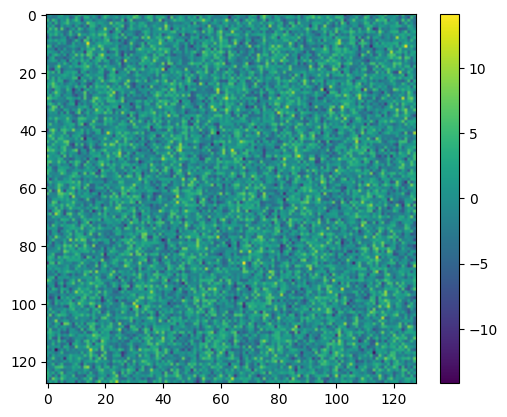

In [32]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


'''
example of the formation of a 2D wave
and the superposition of a random set of them
'''
Npix  = 128
x     = np.linspace(0,128,128)

xmedium   = int(x.max()/2)
xx,yy = np.meshgrid(x-xmedium,x-xmedium)

Kmax = 8 ## 1/pixel
Amax = 0.6 ## rad
N    = 25

KmaxV = np.random.normal(0, Kmax, N)
AmaxV = np.random.normal(0, Amax, N)

waveFtot = np.zeros(xx.shape)

for i in range(N):
  ang    = AmaxV[i]   #### radiants
  k      = KmaxV[i]    ### amplitude of the kvector, determining the wavelìength (as the inverse)

  kx      = k*np.cos(ang)
  ky      = k*np.sin(ang)   ###### k vector
  print (i,kx,ky)
  waveF    = np.sin( kx * xx + ky * yy)
  waveFtot = waveF + waveFtot

plt.imshow(waveFtot)
plt.colorbar()